# Baseline

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from heart_failure.dataset import split_data
from heart_failure.modeling.models import ConjRuleBaseline
from heart_failure.modeling.evaluate import get_metrics, log_metrics
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX
from heart_failure.config.features import CONJ_RULES, CONJ_MIN_MASK_COUNT, CONJ_MIN_TARGET_RATE
from heart_failure.config.train import TEST_SIZE, RANDOM_STATE, VAL_SIZE

2026-06-24 13:33:34.829 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "conjunctive_rules_baseline"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

For the baseline, I'll use the feature I constructed earlier. This is simply a set of rules and their combinations (and/or) that I discovered from EDA. That is high Oldpeak, low MaxHR, etc.

Since the business problem is to detect heart failure, I want to capture as many diseases as possible, although accuracy may suffer. The classes are distributed almost evenly. For this task, I chose the following metrics:
- Recall (pay attention to this first)
- Precision (less important, but very poor values are also undesirable)
- FPR
- PR-AUC

The algorithm for determining model quality is as follows:
1. If Recall is poor, proceed to step 2. Otherwise, proceed to step 3.
2. If PR-AUC is poor, then the model has performed poorly. Otherwise, the threshold chosen is inappropriate and should be revised.
3. If Precision/FPR is low, return to step 2 (for possible threshold revision). Otherwise, the model is satisfactory.

Ideally I want to get Recall 1.

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

In [4]:
model = ConjRuleBaseline(CONJ_RULES, CONJ_MIN_MASK_COUNT, CONJ_MIN_TARGET_RATE)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

## Metrics

In [5]:
print("Train metrics")
train_metrics = get_metrics(y_train, y_train_pred)
train_metrics

Train metrics


precision    0.797170
recall       0.949438
fpr          0.297578
dtype: float64

In [6]:
print("Validate metrics")
val_metrics = get_metrics(y_val, y_val_pred)
val_metrics

Validate metrics


precision    0.775862
recall       0.918367
fpr          0.333333
dtype: float64

In [7]:
print("Test metrics")
test_metrics = get_metrics(y_test, y_test_pred)
test_metrics

Test metrics


precision    0.785714
recall       0.970588
fpr          0.329268
dtype: float64

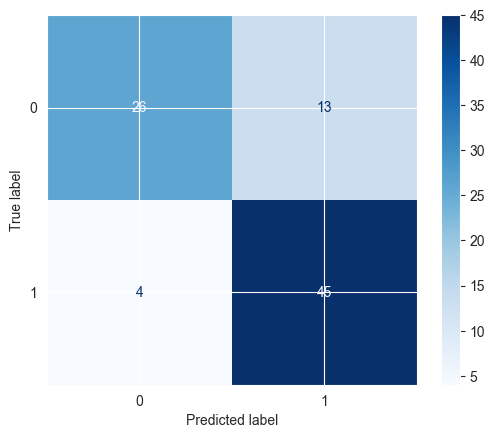

In [8]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

The predictions contain significant number of FN. However, this is the baseline. Let's write down the metrics. If any model performs worse on train than this one, it's not needed.



In [ ]:
with mlflow.start_run(run_name=MODEL_NAME) as run:
    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_dict(CONJ_RULES, "rule_conditions.json")
    mlflow.log_param("conjunctive_min_count", CONJ_MIN_MASK_COUNT)
    mlflow.log_param("conjunctive_min_target_rate", CONJ_MIN_TARGET_RATE)
    mlflow.log_param("random_state", RANDOM_STATE)

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")